In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def get_all_metrics():
    metrics = Path("../results/metrics")

    allFiles=[file for file in metrics.glob("*_metrics.csv") if file.name!= "all_metrics.csv"]


    combine_df = pd.concat(
        [pd.read_csv(file) for file in allFiles],
        ignore_index=True
    )

    combine_df.to_csv("../results/comparison/all_metrics.csv", index=False)
    return combine_df

combine_df = get_all_metrics()
print(combine_df)

                 model  accuracy  precision_macro  recall_macro  f1_macro  \
0        decision_tree  0.946667         0.946292      0.912500  0.925253   
1                  KNN  0.933333         0.899749      0.918182  0.906205   
2  logistic_regression  0.946667         0.921727      0.925758  0.919978   
3        random_forest  0.960000         0.936975      0.934722  0.935214   

    roc_auc  
0  0.994463  
1  0.994493  
2  0.985625  
3  0.996047  


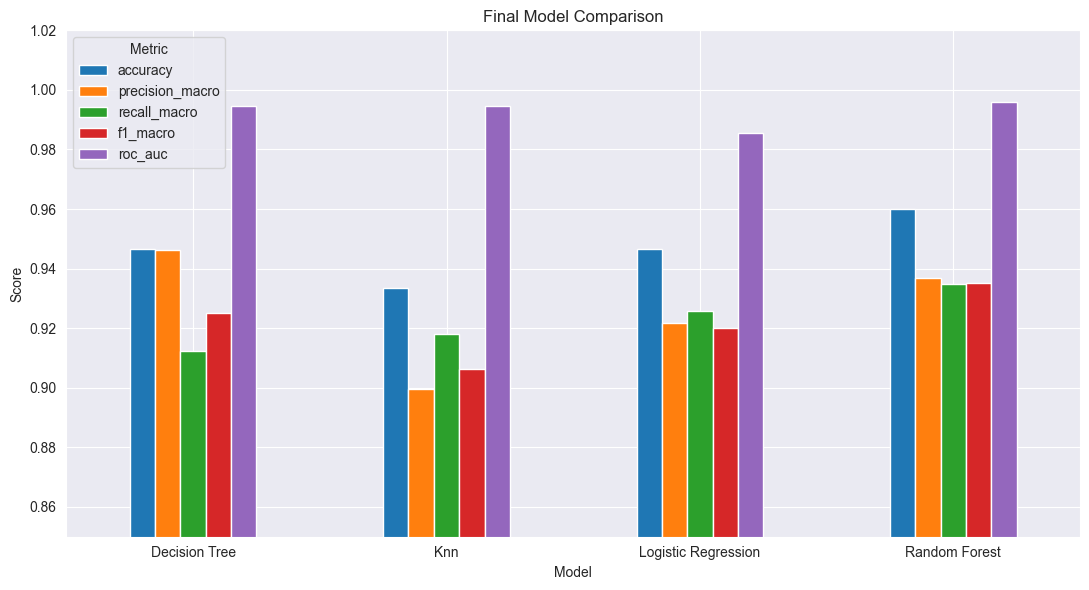

In [31]:
def plot_final_comparison(df):
    metric_cols = [
        col for col in
        ["accuracy", "precision_macro", "recall_macro", "f1_macro", "roc_auc"]
        if col in df.columns
    ]

    plot_df = df[["model"] + metric_cols].copy()

    # Make model names cleaner for the graph
    plot_df["model"] = (
        plot_df["model"]
        .astype(str)
        .str.replace("_", " ", regex=False)
        .str.title()
    )

    ax = plot_df.set_index("model").plot(kind="bar", figsize=(11, 6))
    ax.set_title("Final Model Comparison")
    ax.set_xlabel("Model")
    ax.set_ylabel("Score")
    ax.set_ylim(0.85, 1.02)
    plt.xticks(rotation=0)
    plt.legend(title="Metric")
    plt.tight_layout()

    plt.savefig("../results/comparison/final_model_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
combined_df = get_all_metrics()
plot_final_comparison(combined_df)

Random Forest achieved the best overall performance across all metrics. Logistic Regression was the second-best and remained competitive. Decision Tree and KNN performed worse, with KNN showing the lowest overall performance. While all models had high ROC-AUC, Random Forest consistently performed better across accuracy and F1-score.

                  Model        Class    Recall
0         Decision Tree     Insomnia  0.800000
1         Decision Tree         None  1.000000
2         Decision Tree  Sleep Apnea  0.937500
3                   KNN     Insomnia  0.800000
4                   KNN         None  0.954545
5                   KNN  Sleep Apnea  1.000000
6   Logistic Regression     Insomnia  0.800000
7   Logistic Regression         None  0.977273
8   Logistic Regression  Sleep Apnea  1.000000
9         Random Forest     Insomnia  0.866667
10        Random Forest         None  1.000000
11        Random Forest  Sleep Apnea  0.937500


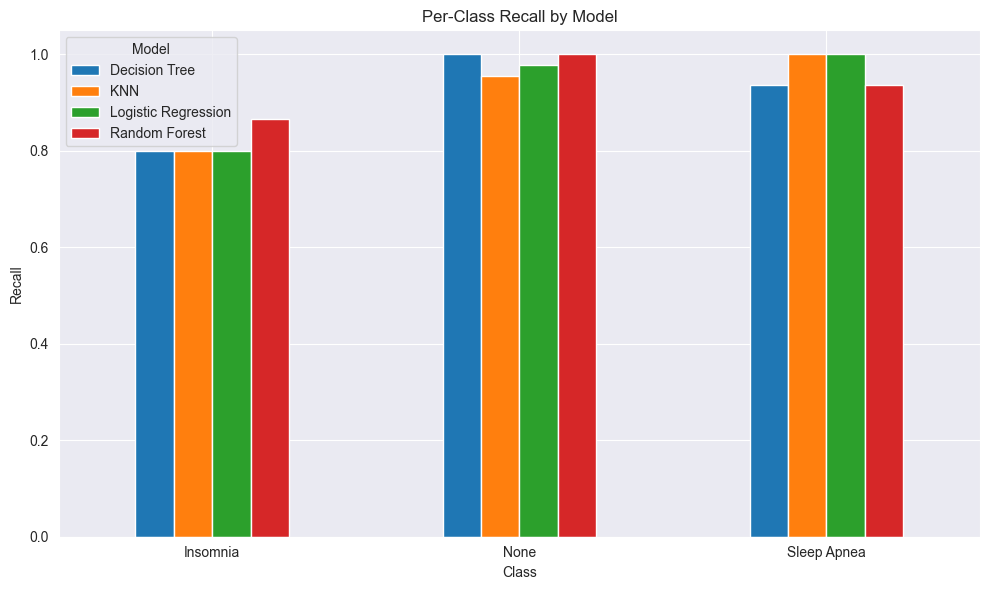

In [34]:
# Class names
classes = ["Insomnia", "None", "Sleep Apnea"]

# Confusion matrices
confusion_matrices = {
    "Decision Tree": np.array([
        [12, 1, 2],
        [0, 44, 0],
        [0, 1, 15]
    ]),
    "KNN": np.array([
        [12, 0, 3],
        [2, 42, 0],
        [0, 0, 16]
    ]),
    "Logistic Regression": np.array([
        [12, 0, 3],
        [1, 43, 0],
        [0, 0, 16]
    ]),
    "Random Forest": np.array([
        [13, 0, 2],
        [0, 44, 0],
        [1, 0, 15]
    ])
}


# Build a dataframe
rows = []
for model_name, cm in confusion_matrices.items():
    row_totals = cm.sum(axis=1)
    recalls = np.diag(cm) / row_totals
    for class_name, recall in zip(classes, recalls):
        rows.append({
            "Model": model_name,
            "Class": class_name,
            "Recall": recall
        })

df = pd.DataFrame(rows)
print(df)

# Pivot for plotting
plot_df = df.pivot(index="Class", columns="Model", values="Recall")

# Plot
ax = plot_df.plot(kind="bar", figsize=(10, 6))
ax.set_title("Per-Class Recall by Model")
ax.set_xlabel("Class")
ax.set_ylabel("Recall")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()

plt.savefig("../results/comparison/per_class_recall_by_model.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

The differences in recall suggest that some classes are inherently harder to distinguish, and model performance depends on how well they handle these difficult classes.